# The Scandinavia Paradox: Happiness & Social Indicators
**Course:** Social Data Analysis and Visualization — DTU  
**Project:** Assignment A — Basic Stats & Data Analysis  
**Data Sources:**
- World Happiness Report 2026 (`WHR26_Data_Figure_2_1.xlsx`)
- European Social Survey Round 11 — individual microdata (`ESS11e04_1.csv`)

**Research Question:** Why do Scandinavian countries rank as the world's happiest while simultaneously reporting some of the highest antidepressant usage? This notebook integrates WHR happiness scores with ESS social indicators — cleaning raw individual-level survey responses, aggregating to country level, and producing country-level visualisations.

---
## 0. Imports & Configuration

In [18]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pycountry

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

# ── Colour palette ───────────────────────────────────────────────────────────
SCAND_COLOR  = '#E63946'   # vivid red  — Scandinavian countries
EUROPE_COLOR = '#457B9D'   # steel blue — other European countries

SCAND_COUNTRIES = {'Denmark', 'Norway', 'Sweden', 'Finland', 'Iceland'}

# ── File paths ───────────────────────────────────────────────────────────────
WHR_PATH = 'data/WHR26_Data_Figure_2.1.xlsx'
ESS_PATH = 'data/ESS11e04_1.csv'

# ── Target ESS columns (raw individual-level) ────────────────────────────────
ESS_COLS = ['inprdsc', 'ppltrst', 'trstplt', 'stfdem', 'sclmeet', 'sclact', 'atchctr']

# Human-readable labels (used in all plots & tables)
ESS_LABELS = {
    'inprdsc': 'No. of Close Confidants',
    'ppltrst': 'Trust in People',
    'trstplt': 'Trust in Politicians',
    'stfdem' : 'Satisfaction w/ Democracy',
    'sclmeet': 'Social Meeting Freq.',
    'sclact' : 'Social Activity (rel. to peers)',
    'atchctr': 'Attachment to Country',
}

print('\u2713 Imports and configuration complete.')

✓ Imports and configuration complete.


---
## 1. Data Cleaning & Preprocessing

### 1a. ESS Individual-Level Cleaning — Removing Sentinel Codes

The ESS encodes non-substantive answers (Refusal, Don't Know, No Answer) with out-of-range sentinel integers. Per the **ESS Round 11 codebook**, the valid response ranges and their corresponding sentinels are:

| Variable | Question | Valid range | Sentinel values → NaN |
|---|---|---|---|
| `inprdsc` | No. of close confidants | 0–6 | 77, 88, 99 |
| `ppltrst` | Trust in people | 0–10 | 77, 88, 99 |
| `trstplt` | Trust in politicians | 0–10 | 77, 88, 99 |
| `stfdem` | Satisfaction w/ democracy | 0–10 | 77, 88, 99 |
| `sclmeet` | Social meeting frequency | 1–7 | 77, 88, 99 |
| `sclact` | Social activity vs peers | 1–5 | 7, 8, 9 |
| `atchctr` | Attachment to country | 0–10 | 77, 88, 99 |

In [19]:
# ── Codebook-derived valid ranges: {column: (valid_min, valid_max)} ───────────
# Source: ESS Round 11 codebook (ESS11e04_1_codebook.html)
ESS_VALID_RANGES = {
    'inprdsc': (0, 6),    # 0=None, 1=1 person, 2=2, 3=3, 4=4-6, 5=7-9, 6=10+
    'ppltrst': (0, 10),   # 0=No trust ... 10=Complete trust
    'trstplt': (0, 10),
    'stfdem' : (0, 10),
    'sclmeet': (1, 7),    # 1=Never ... 7=Every day
    'sclact' : (1, 5),    # 1=Much less than most ... 5=Much more than most
    'atchctr': (0, 10),
}


def clean_ess_sentinels(df: pd.DataFrame, valid_ranges: dict) -> pd.DataFrame:
    """
    Replace ESS sentinel / refusal codes with NaN for each target column.

    Any value outside the codebook-specified [valid_min, valid_max] interval
    is treated as a missing value and set to NaN.

    Parameters
    ----------
    df           : pd.DataFrame  -- raw ESS individual-level data
    valid_ranges : dict          -- {col: (min_valid, max_valid)}

    Returns
    -------
    pd.DataFrame with sentinels replaced by NaN.
    """
    df = df.copy()
    for col, (lo, hi) in valid_ranges.items():
        if col not in df.columns:
            continue
        mask_sentinel = (df[col] < lo) | (df[col] > hi)
        n_removed = mask_sentinel.sum()
        df.loc[mask_sentinel, col] = np.nan
        print(f'  {col:10s}: {n_removed:5d} sentinel values removed  '
              f'(valid [{lo}-{hi}])  =>  {df[col].notna().sum():,} valid responses remain')
    return df


# ── Load only the columns we need (saves memory on the 691-column file) ──────
LOAD_COLS = ['cntry'] + ESS_COLS
ess_raw = pd.read_csv(ESS_PATH, usecols=LOAD_COLS, low_memory=False)

print(f'ESS raw shape: {ess_raw.shape}  '
      f'({ess_raw["cntry"].nunique()} countries, {len(ess_raw):,} respondents)\n')
print('Applying sentinel-code cleaning...')
ess_clean = clean_ess_sentinels(ess_raw, ESS_VALID_RANGES)
print(f'\n\u2713 Cleaning complete.  NaN rate per column:')
print((ess_clean[ESS_COLS].isna().mean() * 100).round(2).rename('% NaN').to_string())

ESS raw shape: (50116, 8)  (30 countries, 50,116 respondents)

Applying sentinel-code cleaning...
  inprdsc   :   317 sentinel values removed  (valid [0-6])  =>  49,799 valid responses remain
  ppltrst   :   144 sentinel values removed  (valid [0-10])  =>  49,972 valid responses remain
  trstplt   :   779 sentinel values removed  (valid [0-10])  =>  49,337 valid responses remain
  stfdem    :  1733 sentinel values removed  (valid [0-10])  =>  48,383 valid responses remain
  sclmeet   :   135 sentinel values removed  (valid [1-7])  =>  49,981 valid responses remain
  sclact    :   681 sentinel values removed  (valid [1-5])  =>  49,435 valid responses remain
  atchctr   :   246 sentinel values removed  (valid [0-10])  =>  49,870 valid responses remain

✓ Cleaning complete.  NaN rate per column:
inprdsc    0.63
ppltrst    0.29
trstplt    1.55
stfdem     3.46
sclmeet    0.27
sclact     1.36
atchctr    0.49


### 1b. Aggregate to Country Level

The WHR is country-level; we collapse the cleaned ESS individual responses by taking the **mean** (and std, count for reference) for each target variable within each country.

In [20]:
# ── Country-level aggregation ────────────────────────────────────────────────
ess_country = (
    ess_clean
    .groupby('cntry')[ESS_COLS]
    .agg(['mean', 'std', 'count'])
)

# Flatten multi-level column index: ('ppltrst', 'mean') -> 'ppltrst_mean'
ess_country.columns = ['_'.join(col) for col in ess_country.columns]
ess_country = ess_country.reset_index()

ESS_MEAN_COLS = [f'{c}_mean' for c in ESS_COLS]

print(f'Country-level ESS summary: {ess_country.shape[0]} countries')
ess_country[['cntry'] + ESS_MEAN_COLS].round(3)

Country-level ESS summary: 30 countries


,cntry,inprdsc_mean,ppltrst_mean,trstplt_mean,stfdem_mean,sclmeet_mean,sclact_mean,atchctr_mean
0,AT,2.969,5.881,3.774,5.745,4.892,2.803,8.360
1,BE,3.287,5.544,4.173,5.268,5.145,2.715,6.407
2,BG,2.115,3.732,2.212,3.298,4.974,2.862,8.001
3,CH,3.464,5.844,5.541,7.526,5.103,2.769,7.927
4,CY,2.435,4.060,2.681,4.496,4.006,2.447,8.247
5,DE,3.508,5.190,4.004,5.697,4.846,2.703,7.212
6,EE,2.590,5.692,3.443,5.108,4.213,2.567,7.807
7,ES,2.917,5.298,2.784,4.760,5.254,2.732,7.714
8,FI,3.174,6.906,5.311,6.779,4.871,2.723,8.630
9,FR,2.832,4.555,3.763,4.234,5.241,2.928,8.012


### 1c. Country Code Mapping — ISO Alpha-2 to Full Name

ESS uses ISO 3166-1 alpha-2 codes. We map these to full country names to join with the WHR.

In [21]:
# Manual overrides for names that differ between pycountry and the WHR
MANUAL_OVERRIDES = {
    'AT': 'Austria',      'BE': 'Belgium',       'BG': 'Bulgaria',
    'CH': 'Switzerland',  'CY': 'Cyprus',         'DE': 'Germany',
    'DK': 'Denmark',      'EE': 'Estonia',        'ES': 'Spain',
    'FI': 'Finland',      'FR': 'France',         'GB': 'United Kingdom',
    'GR': 'Greece',       'HR': 'Croatia',        'HU': 'Hungary',
    'IE': 'Ireland',      'IL': 'Israel',         'IS': 'Iceland',
    'IT': 'Italy',        'LT': 'Lithuania',      'LV': 'Latvia',
    'ME': 'Montenegro',   'NL': 'Netherlands',    'NO': 'Norway',
    'PL': 'Poland',       'PT': 'Portugal',       'RS': 'Serbia',
    'SE': 'Sweden',       'SI': 'Slovenia',       'SK': 'Slovakia',
    'UA': 'Ukraine',
}


def iso2_to_name(code: str) -> str | None:
    """Map ISO 3166-1 alpha-2 -> WHR-compatible country name."""
    if code in MANUAL_OVERRIDES:
        return MANUAL_OVERRIDES[code]
    try:
        return pycountry.countries.get(alpha_2=code).name
    except AttributeError:
        return None


ess_country['country'] = ess_country['cntry'].apply(iso2_to_name)

unmapped = ess_country[ess_country['country'].isna()]['cntry'].tolist()
if unmapped:
    print(f'WARNING - Unmapped ISO codes: {unmapped}')
else:
    print('\u2713 All ISO codes mapped successfully.')

print(ess_country[['cntry', 'country']].to_string(index=False))

✓ All ISO codes mapped successfully.
cntry        country
   AT        Austria
   BE        Belgium
   BG       Bulgaria
   CH    Switzerland
   CY         Cyprus
   DE        Germany
   EE        Estonia
   ES          Spain
   FI        Finland
   FR         France
   GB United Kingdom
   GR         Greece
   HR        Croatia
   HU        Hungary
   IE        Ireland
   IL         Israel
   IS        Iceland
   IT          Italy
   LT      Lithuania
   LV         Latvia
   ME     Montenegro
   NL    Netherlands
   NO         Norway
   PL         Poland
   PT       Portugal
   RS         Serbia
   SE         Sweden
   SI       Slovenia
   SK       Slovakia
   UA        Ukraine


---
## 2. Load WHR & Merge

We take the most recent year (2025) from the WHR and inner-join with the aggregated ESS data.

In [22]:
# ── Load WHR, keep latest year ────────────────────────────────────────────────
whr_raw = pd.read_excel(WHR_PATH, sheet_name=0)
latest_year = whr_raw['Year'].max()

whr = (
    whr_raw[whr_raw['Year'] == latest_year]
    .rename(columns={
        'Country name'                   : 'country',
        'Life evaluation (3-year average)': 'happiness_score',
        'Rank'                           : 'happiness_rank',
    })
    [['country', 'happiness_score', 'happiness_rank']]
    .reset_index(drop=True)
)
print(f'WHR {latest_year}: {len(whr)} countries loaded.')

# ── Inner join on country name ────────────────────────────────────────────────
df = pd.merge(
    ess_country[['cntry', 'country'] + ESS_MEAN_COLS],
    whr,
    on='country',
    how='inner'
)

# ── Drop non-European countries (Israel present in ESS but not geographically European)
NON_EUROPEAN = {'Israel'}
df = df[~df['country'].isin(NON_EUROPEAN)].reset_index(drop=True)

# ── Flag Scandinavian cluster ─────────────────────────────────────────────────
df['is_scandinavian'] = df['country'].isin(SCAND_COUNTRIES)

print(f'\nMerged European dataset: {len(df)} countries')
print(f"  Scandinavian : {df['is_scandinavian'].sum()} "
      f"({', '.join(sorted(df[df['is_scandinavian']]['country']))})")
print(f"  Other Europe : {(~df['is_scandinavian']).sum()}")

df[['country', 'cntry', 'happiness_rank', 'happiness_score', 'is_scandinavian']]\
  .sort_values('happiness_rank').reset_index(drop=True)

WHR 2025: 147 countries loaded.

Merged European dataset: 29 countries
  Scandinavian : 4 (Finland, Iceland, Norway, Sweden)
  Other Europe : 25


,country,cntry,happiness_rank,happiness_score,is_scandinavian
0,Finland,FI,1,7.764,True
1,Iceland,IS,2,7.540,True
2,Sweden,SE,5,7.255,True
3,Norway,NO,6,7.242,True
4,Netherlands,NL,7,7.223,False
5,Switzerland,CH,10,7.018,False
6,Ireland,IE,13,6.928,False
7,Belgium,BE,14,6.926,False
8,Germany,DE,17,6.882,False
9,Slovenia,SI,18,6.868,False


---
## 3. Exploratory Data Analysis

### 3a. Correlation Heatmap — ESS Social Indicators x Happiness Score

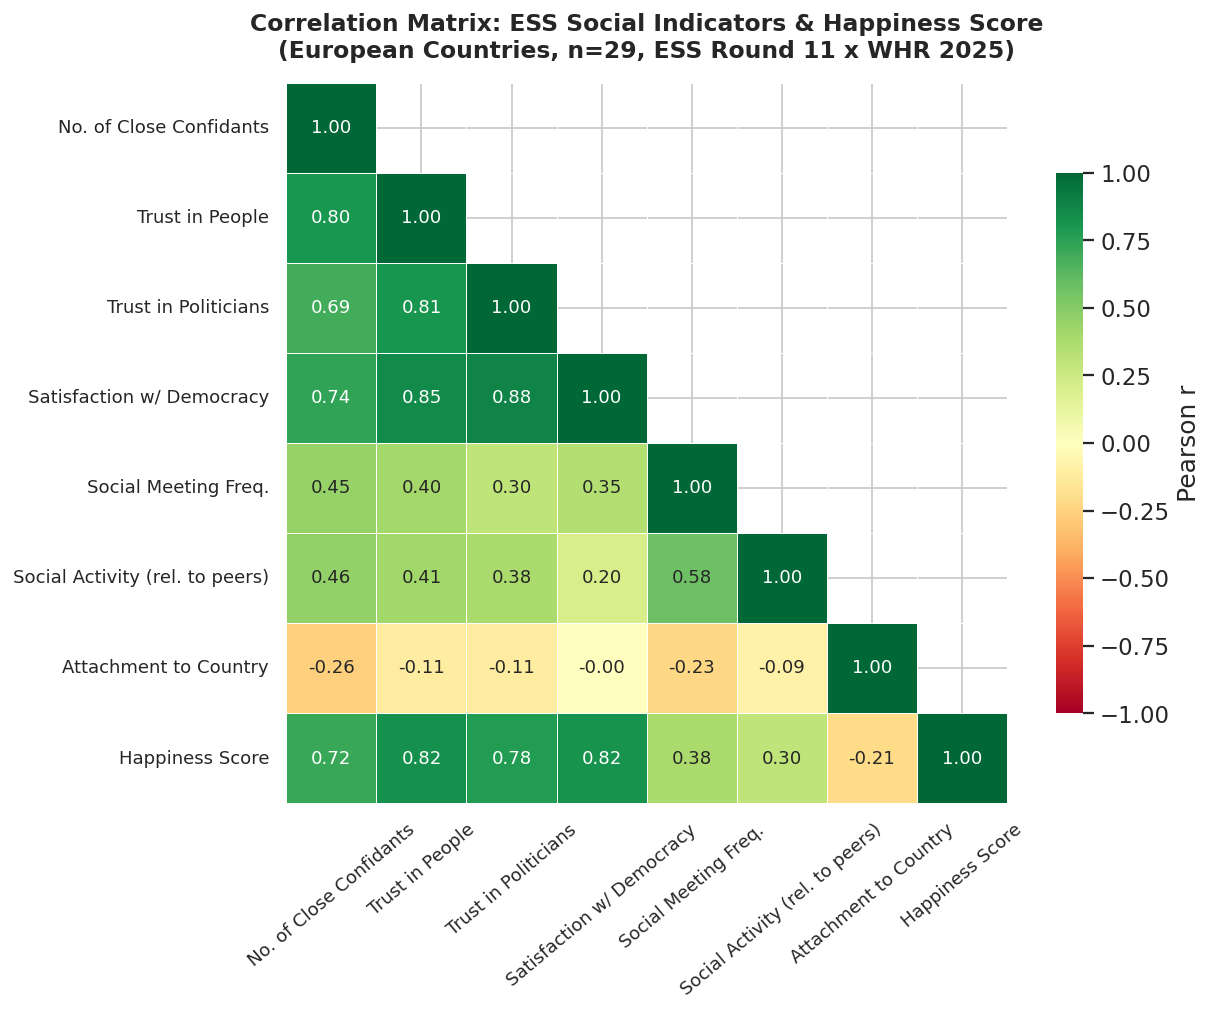

✓ Saved fig_correlation_heatmap.png


In [23]:
label_map = {f'{k}_mean': v for k, v in ESS_LABELS.items()}
label_map['happiness_score'] = 'Happiness Score'

corr_cols = ESS_MEAN_COLS + ['happiness_score']
corr_matrix = df[corr_cols].rename(columns=label_map).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # lower triangle only

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    annot_kws={'size': 10},
    cbar_kws={'label': 'Pearson r', 'shrink': 0.75},
)
ax.set_title(
    f'Correlation Matrix: ESS Social Indicators & Happiness Score\n'
    f'(European Countries, n={len(df)}, ESS Round 11 x WHR {latest_year})',
    fontsize=13, fontweight='bold', pad=14
)
ax.tick_params(axis='x', rotation=40, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('\u2713 Saved fig_correlation_heatmap.png')

### 3b. Country-Level Bar Charts — All 7 ESS Indicators

One bar chart per indicator. Countries are sorted by value. Scandinavian bars are highlighted in red.

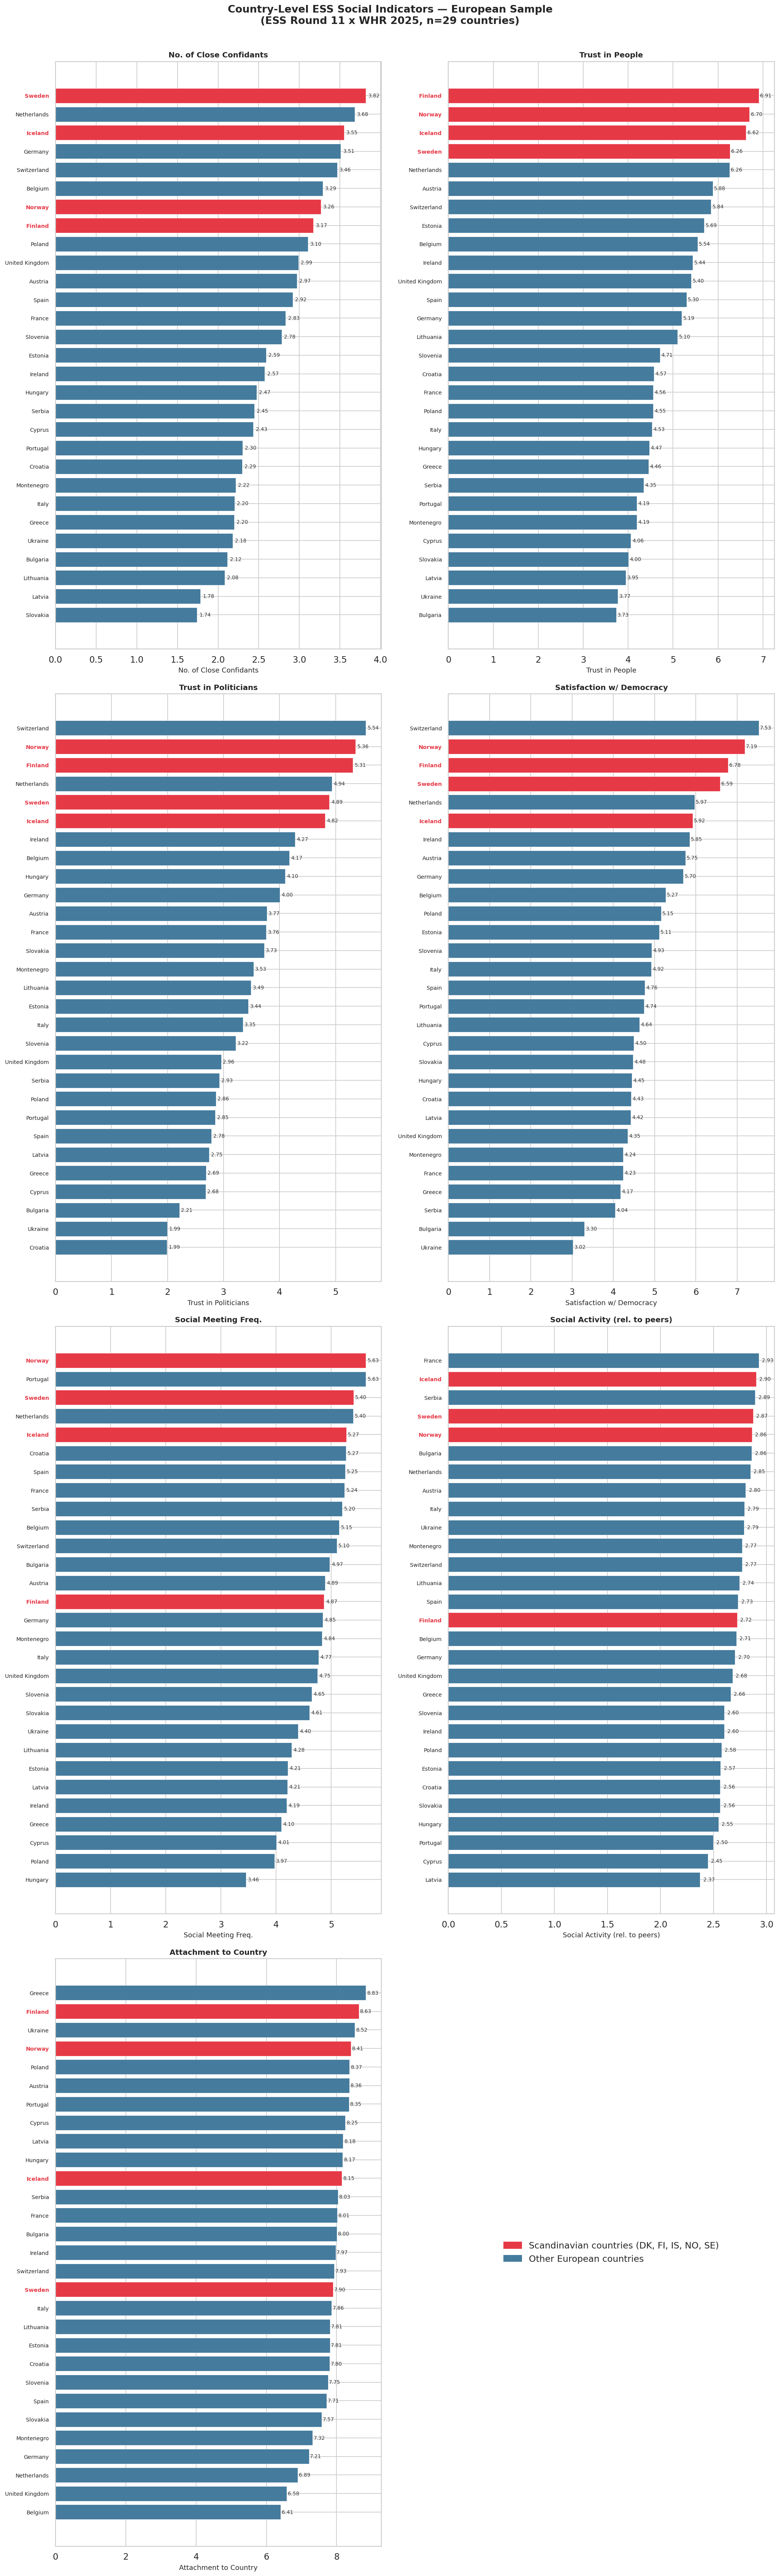

✓ Saved fig_country_bars_all_indicators.png


In [24]:
def plot_country_bars(df: pd.DataFrame, col: str, label: str,
                      ax: plt.Axes, highlight_set: set) -> None:
    """
    Horizontal bar chart of `col` across all countries, sorted ascending.
    Bars for countries in `highlight_set` are coloured in SCAND_COLOR.
    """
    plot_df = (
        df[['country', col, 'is_scandinavian']]
        .dropna(subset=[col])
        .sort_values(col, ascending=True)
    )
    colors = [SCAND_COLOR if s else EUROPE_COLOR for s in plot_df['is_scandinavian']]
    bars = ax.barh(plot_df['country'], plot_df[col],
                   color=colors, edgecolor='white', linewidth=0.4)

    for bar, val in zip(bars, plot_df[col]):
        ax.text(bar.get_width() + 0.03,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=7.5, color='#333333')

    # Bold + colour Scandinavian country names on y-axis
    ax.set_yticklabels(plot_df['country'], fontsize=8)
    for tick_label, country in zip(ax.get_yticklabels(), plot_df['country']):
        if country in highlight_set:
            tick_label.set_color(SCAND_COLOR)
            tick_label.set_fontweight('bold')

    ax.set_xlabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')


fig, axes = plt.subplots(4, 2, figsize=(16, 52))
axes_flat = axes.flatten()

for i, (col, label) in enumerate(ESS_LABELS.items()):
    plot_country_bars(df, f'{col}_mean', label, axes_flat[i], SCAND_COUNTRIES)

# Use the spare 8th panel as a legend
ax_legend = axes_flat[7]
ax_legend.axis('off')
ax_legend.legend(
    handles=[
        mpatches.Patch(color=SCAND_COLOR,  label='Scandinavian countries (DK, FI, IS, NO, SE)'),
        mpatches.Patch(color=EUROPE_COLOR, label='Other European countries'),
    ],
    loc='center', fontsize=13, frameon=False
)

fig.suptitle(
    f'Country-Level ESS Social Indicators — European Sample\n'
    f'(ESS Round 11 x WHR {latest_year}, n={len(df)} countries)',
    fontsize=15, fontweight='bold', y=1.002
)
plt.tight_layout()
plt.savefig('fig_country_bars_all_indicators.png', bbox_inches='tight')
plt.show()
print('\u2713 Saved fig_country_bars_all_indicators.png')

### 3c. The Paradox Visualization — Happiness Score vs. Social Health Index

A **Social Health Index (SHI)** is constructed as the min-max normalised average of the three most directly wellbeing-adjacent ESS indicators:
- `ppltrst` — Trust in People
- `stfdem`  — Satisfaction with Democracy  
- `sclmeet` — Social Meeting Frequency

Each component is normalised to [0, 1] across the European sample before averaging, making the composite scale-invariant.

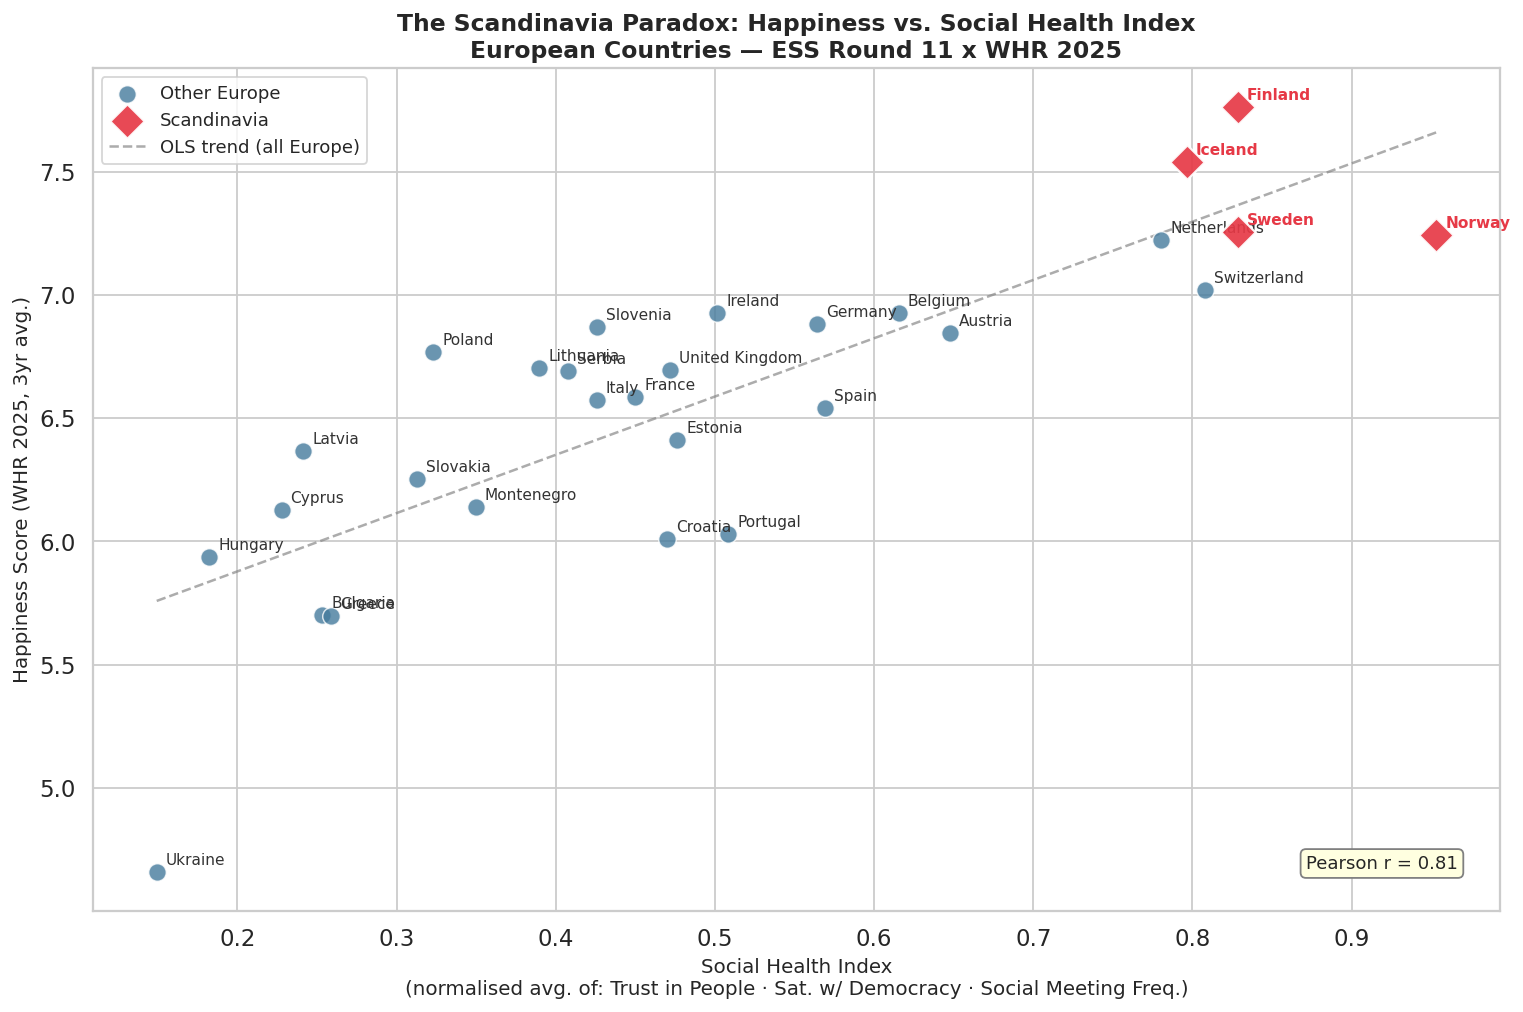

✓ Saved fig_paradox_scatter.png


In [25]:
# ── Build Social Health Index ─────────────────────────────────────────────────
SHI_COMPONENTS = ['ppltrst_mean', 'stfdem_mean', 'sclmeet_mean']

df_plot = df.copy()
for comp in SHI_COMPONENTS:
    lo, hi = df_plot[comp].min(), df_plot[comp].max()
    df_plot[f'{comp}_norm'] = (df_plot[comp] - lo) / (hi - lo)

df_plot['social_health_index'] = df_plot[[f'{c}_norm' for c in SHI_COMPONENTS]].mean(axis=1)

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

other_df = df_plot[~df_plot['is_scandinavian']]
scand_df = df_plot[ df_plot['is_scandinavian']]

ax.scatter(
    other_df['social_health_index'], other_df['happiness_score'],
    s=95, color=EUROPE_COLOR, alpha=0.80, edgecolors='white', linewidth=0.8,
    label='Other Europe', zorder=3,
)
ax.scatter(
    scand_df['social_health_index'], scand_df['happiness_score'],
    s=180, color=SCAND_COLOR, alpha=0.92, edgecolors='white', linewidth=1.2,
    label='Scandinavia', zorder=5, marker='D',
)

# Label every country
for _, row in df_plot.iterrows():
    color = SCAND_COLOR if row['is_scandinavian'] else '#333333'
    fw    = 'bold'  if row['is_scandinavian'] else 'normal'
    ax.annotate(
        row['country'],
        xy=(row['social_health_index'], row['happiness_score']),
        xytext=(5, 4), textcoords='offset points',
        fontsize=8.5, color=color, fontweight=fw,
    )

# OLS trend line across all European countries
valid = df_plot[['social_health_index', 'happiness_score']].dropna()
z = np.polyfit(valid['social_health_index'], valid['happiness_score'], 1)
x_line = np.linspace(valid['social_health_index'].min(),
                     valid['social_health_index'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), '--', color='grey',
        linewidth=1.4, alpha=0.65, label='OLS trend (all Europe)')

# Annotate Pearson r
r = valid['social_health_index'].corr(valid['happiness_score'])
ax.text(0.97, 0.05, f'Pearson r = {r:.2f}',
        transform=ax.transAxes, ha='right', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='grey'))

ax.set_xlabel(
    'Social Health Index\n'
    '(normalised avg. of: Trust in People · Sat. w/ Democracy · Social Meeting Freq.)',
    fontsize=11
)
ax.set_ylabel(f'Happiness Score (WHR {latest_year}, 3yr avg.)', fontsize=11)
ax.set_title(
    f'The Scandinavia Paradox: Happiness vs. Social Health Index\n'
    f'European Countries — ESS Round 11 x WHR {latest_year}',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('fig_paradox_scatter.png', bbox_inches='tight')
plt.show()
print('\u2713 Saved fig_paradox_scatter.png')

### 3d. Happiness Score Country Ranking

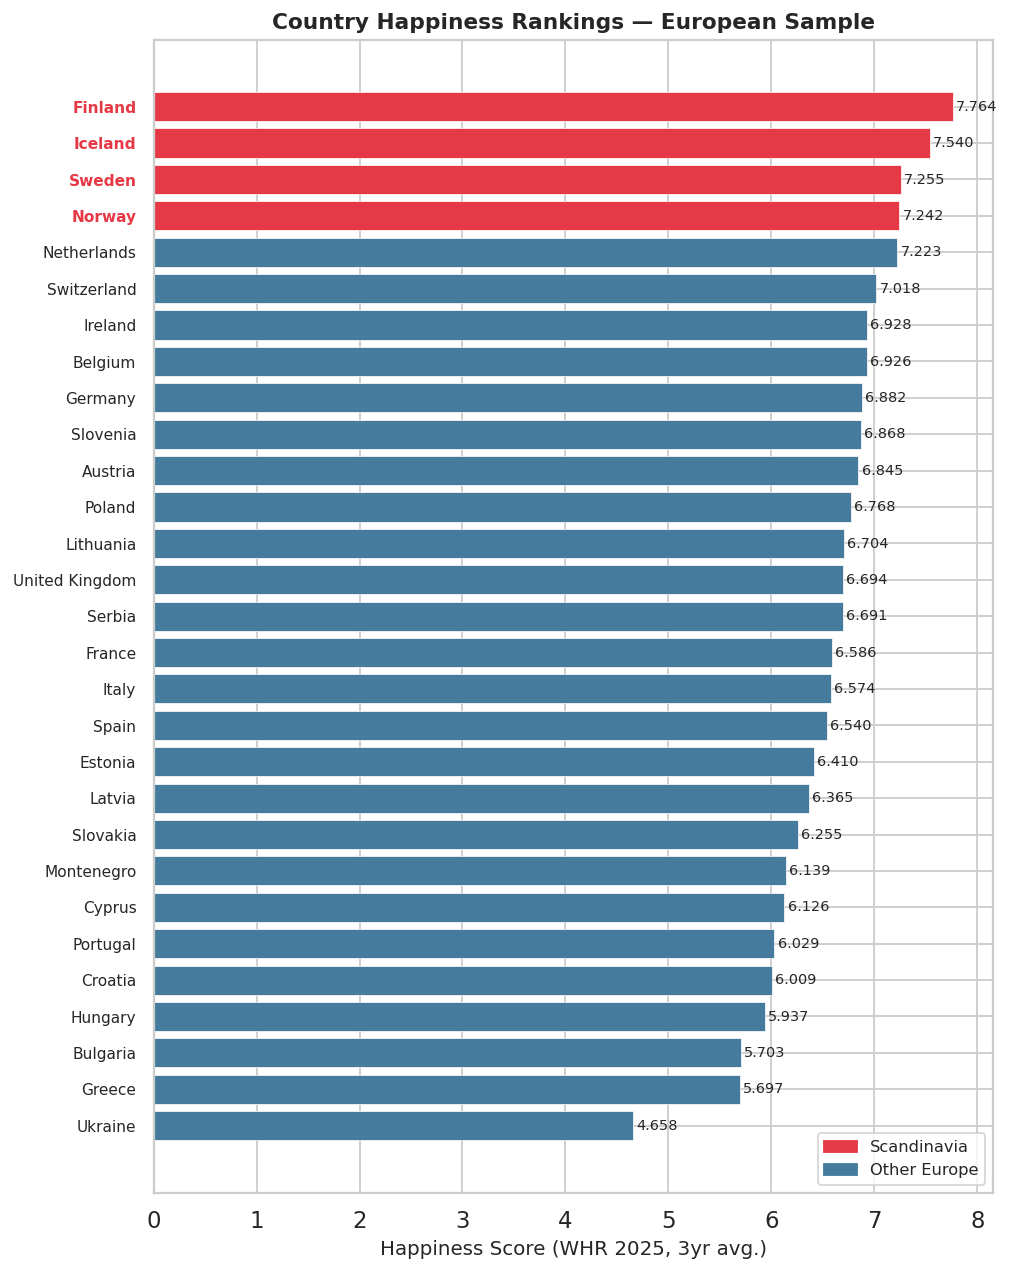

✓ Saved fig_happiness_ranking.png


In [26]:
fig, ax = plt.subplots(figsize=(8, 10))

plot_df = df[['country', 'happiness_score', 'is_scandinavian']]\
            .sort_values('happiness_score', ascending=True)

colors = [SCAND_COLOR if s else EUROPE_COLOR for s in plot_df['is_scandinavian']]
bars = ax.barh(plot_df['country'], plot_df['happiness_score'],
               color=colors, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, plot_df['happiness_score']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)

ax.set_yticklabels(plot_df['country'], fontsize=8.5)
for tick_label, country in zip(ax.get_yticklabels(), plot_df['country']):
    if country in SCAND_COUNTRIES:
        tick_label.set_color(SCAND_COLOR)
        tick_label.set_fontweight('bold')

ax.legend(
    handles=[
        mpatches.Patch(color=SCAND_COLOR,  label='Scandinavia'),
        mpatches.Patch(color=EUROPE_COLOR, label='Other Europe'),
    ],
    fontsize=9, loc='lower right'
)
ax.set_xlabel(f'Happiness Score (WHR {latest_year}, 3yr avg.)', fontsize=11)
ax.set_title('Country Happiness Rankings — European Sample', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_happiness_ranking.png', bbox_inches='tight')
plt.show()
print('\u2713 Saved fig_happiness_ranking.png')

### 3e. Radar Chart — Scandinavian Countries vs. European Average

Each normalised ESS indicator is shown as a spoke, allowing a quick visual comparison of each Nordic country's social indicator profile against the European mean.

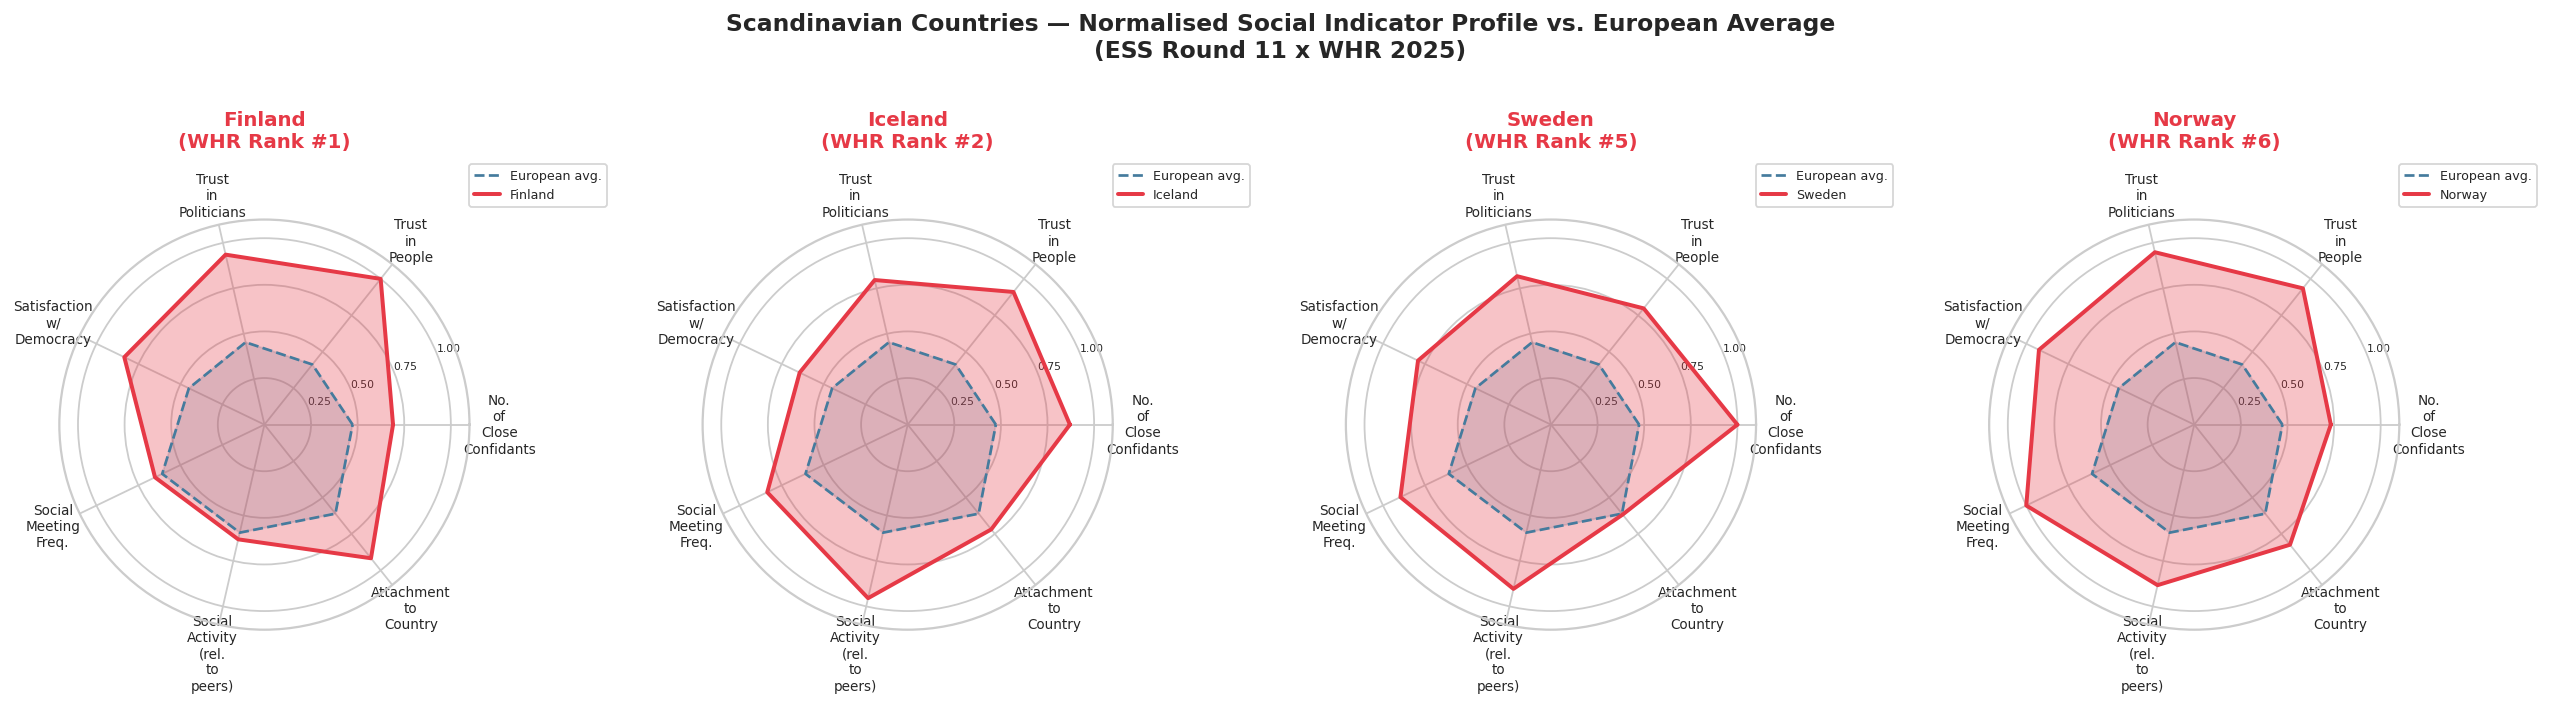

✓ Saved fig_radar_scandinavia.png


In [27]:
# ── Normalise all ESS mean indicators to [0,1] across European countries ──────
df_radar = df.copy()
for col in ESS_MEAN_COLS:
    lo, hi = df_radar[col].min(), df_radar[col].max()
    df_radar[f'{col}_norm'] = (df_radar[col] - lo) / (hi - lo)

NORM_COLS    = [f'{c}_mean_norm' for c in ESS_COLS]
spoke_labels = list(ESS_LABELS.values())
N_spokes     = len(spoke_labels)

europe_mean = df_radar[NORM_COLS].mean().values

angles = np.linspace(0, 2 * np.pi, N_spokes, endpoint=False).tolist()
angles += angles[:1]   # close polygon

scand_rows = df_radar[df_radar['is_scandinavian']].sort_values('happiness_rank')
n_scand    = len(scand_rows)

fig, axes = plt.subplots(1, n_scand, figsize=(5 * n_scand, 5),
                         subplot_kw=dict(polar=True))
if n_scand == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, scand_rows.iterrows()):
    values    = row[NORM_COLS].values.tolist() + [row[NORM_COLS].values[0]]
    euro_vals = europe_mean.tolist()            + [europe_mean[0]]

    ax.fill(angles, euro_vals, color=EUROPE_COLOR, alpha=0.20)
    ax.plot(angles, euro_vals, color=EUROPE_COLOR, linewidth=1.5,
            linestyle='--', label='European avg.')
    ax.fill(angles, values, color=SCAND_COLOR, alpha=0.30)
    ax.plot(angles, values, color=SCAND_COLOR, linewidth=2.2, label=row['country'])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([lbl.replace(' ', '\n') for lbl in spoke_labels], fontsize=7.5)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=6)
    ax.set_ylim(0, 1.1)
    ax.set_title(
        f"{row['country']}\n(WHR Rank #{int(row['happiness_rank'])})",
        fontsize=11, fontweight='bold', pad=14, color=SCAND_COLOR
    )
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=7)

fig.suptitle(
    f'Scandinavian Countries — Normalised Social Indicator Profile vs. European Average\n'
    f'(ESS Round 11 x WHR {latest_year})',
    fontsize=13, fontweight='bold', y=1.04
)
plt.tight_layout()
plt.savefig('fig_radar_scandinavia.png', bbox_inches='tight')
plt.show()
print('\u2713 Saved fig_radar_scandinavia.png')

---
## 4. Preliminary Data Analysis & Stats

### 4a. Descriptive Statistics — All Countries

In [28]:
desc_rename = {f'{k}_mean': v for k, v in ESS_LABELS.items()}
desc_rename['happiness_score'] = 'Happiness Score'

desc_cols = ESS_MEAN_COLS + ['happiness_score']

stats_all = (
    df[desc_cols]
    .rename(columns=desc_rename)
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .T.round(3)
)
stats_all.index.name = 'Indicator'

print(f'=== Descriptive Statistics — All European Countries (N={len(df)}) ===')
display(stats_all.style
        .format(precision=3)
        .background_gradient(subset=['mean'], cmap='Blues'))

=== Descriptive Statistics — All European Countries (N=29) ===


,mean,median,std,min,max
Indicator,,,,,
No. of Close Confidants,2.723,2.590,0.581,1.740,3.818
Trust in People,5.042,4.705,0.932,3.732,6.906
Trust in Politicians,3.600,3.492,1.006,1.992,5.541
Satisfaction w/ Democracy,5.048,4.760,1.072,3.023,7.526
Social Meeting Freq.,4.778,4.846,0.551,3.457,5.628
Social Activity (rel. to peers),2.703,2.723,0.147,2.374,2.928
Attachment to Country,7.888,7.969,0.568,6.407,8.832
Happiness Score,6.565,6.691,0.634,4.658,7.764


### 4b. Country-Level Detail Table

In [29]:
detail = (
    df[['country', 'happiness_rank', 'happiness_score', 'is_scandinavian'] + ESS_MEAN_COLS]
    .rename(columns={**desc_rename, 'happiness_rank': 'WHR Rank', 'is_scandinavian': 'Scandinavia'})
    .sort_values('WHR Rank')
    .set_index('country')
    .round(3)
)

def highlight_scand(row):
    """Light red background for Scandinavian country rows."""
    return ['background-color: #fde8e9' if row['Scandinavia'] else '' for _ in row]

print('=== Country-Level Detail — sorted by WHR Rank ===')
display(
    detail.style
    .apply(highlight_scand, axis=1)
    .format(precision=3)
    .background_gradient(subset=['Happiness Score'], cmap='YlGn')
)

=== Country-Level Detail — sorted by WHR Rank ===


,WHR Rank,Happiness Score,Scandinavia,No. of Close Confidants,Trust in People,Trust in Politicians,Satisfaction w/ Democracy,Social Meeting Freq.,Social Activity (rel. to peers),Attachment to Country
country,,,,,,,,,,
Finland,1,7.764,True,3.174,6.906,5.311,6.779,4.871,2.723,8.630
Iceland,2,7.540,True,3.548,6.621,4.815,5.919,5.272,2.903,8.150
Sweden,5,7.255,True,3.818,6.264,4.890,6.587,5.403,2.874,7.903
Norway,6,7.242,True,3.263,6.700,5.358,7.186,5.628,2.863,8.405
Netherlands,7,7.223,False,3.679,6.255,4.937,5.965,5.396,2.849,6.895
Switzerland,10,7.018,False,3.464,5.844,5.541,7.526,5.103,2.769,7.927
Ireland,13,6.928,False,2.574,5.436,4.273,5.850,4.194,2.600,7.969
Belgium,14,6.926,False,3.287,5.544,4.173,5.268,5.145,2.715,6.407
Germany,17,6.882,False,3.508,5.190,4.004,5.697,4.846,2.703,7.212


### 4c. Correlation with Happiness Score — Ranked Summary

In [30]:
def compute_ranked_correlations(df_subset: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Pearson r between each ESS mean indicator and Happiness Score.
    Returns a DataFrame sorted by absolute correlation (descending).
    """
    corr_series = (
        df_subset[ESS_MEAN_COLS + ['happiness_score']]
        .corr()['happiness_score']
        .drop('happiness_score')
        .rename(index={f'{k}_mean': v for k, v in ESS_LABELS.items()})
    )
    out = pd.DataFrame({'Indicator': corr_series.index, 'Pearson r': corr_series.values})
    out['|r|'] = out['Pearson r'].abs()
    out = out.sort_values('|r|', ascending=False).drop(columns='|r|').reset_index(drop=True)
    out.index = out.index + 1
    out.index.name = 'Rank'
    return out


corr_table = compute_ranked_correlations(df)

print(f'=== Pearson Correlations with Happiness Score — All European Countries (N={len(df)}) ===')
print('  (Ranked by |r|, descending)\n')
display(
    corr_table.style
    .format({'Pearson r': '{:.3f}'})
    .background_gradient(subset=['Pearson r'], cmap='RdYlGn', vmin=-1, vmax=1)
)

=== Pearson Correlations with Happiness Score — All European Countries (N=29) ===
  (Ranked by |r|, descending)



,Indicator,Pearson r
Rank,,
1,Trust in People,0.824
2,Satisfaction w/ Democracy,0.816
3,Trust in Politicians,0.778
4,No. of Close Confidants,0.717
5,Social Meeting Freq.,0.380
6,Social Activity (rel. to peers),0.299
7,Attachment to Country,-0.215


---
## 5. Summary Export

In [31]:
df.to_csv('scandinavia_paradox_merged.csv', index=False)
print(f'\u2713 Merged dataset        -> scandinavia_paradox_merged.csv  '
      f'({len(df)} rows x {len(df.columns)} cols)')

stats_all.to_csv('scandinavia_paradox_stats.csv')
print(f'\u2713 Descriptive stats      -> scandinavia_paradox_stats.csv')

corr_table.to_csv('scandinavia_paradox_correlations.csv')
print(f'\u2713 Correlations           -> scandinavia_paradox_correlations.csv')

print('\n-- Final Merged Dataset (sorted by WHR Rank) ------')
print(
    df[['country', 'cntry', 'happiness_rank', 'happiness_score',
        'is_scandinavian'] + ESS_MEAN_COLS]
    .sort_values('happiness_rank')
    .round(3)
    .to_string(index=False)
)

✓ Merged dataset        -> scandinavia_paradox_merged.csv  (29 rows x 12 cols)
✓ Descriptive stats      -> scandinavia_paradox_stats.csv
✓ Correlations           -> scandinavia_paradox_correlations.csv

-- Final Merged Dataset (sorted by WHR Rank) ------
       country cntry  happiness_rank  happiness_score  is_scandinavian  inprdsc_mean  ppltrst_mean  trstplt_mean  stfdem_mean  sclmeet_mean  sclact_mean  atchctr_mean
       Finland    FI               1            7.764             True         3.174         6.906         5.311        6.779         4.871        2.723         8.630
       Iceland    IS               2            7.540             True         3.548         6.621         4.815        5.919         5.272        2.903         8.150
        Sweden    SE               5            7.255             True         3.818         6.264         4.890        6.587         5.403        2.874         7.903
        Norway    NO               6            7.242             True       